In [99]:
# !pip install astropy
# !pip install scikit-image

import os

from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.patches import Ellipse
# from matplotlib.patches import Circle

import re
from astropy.wcs import WCS

from skimage.draw import ellipse
from skimage.draw import disk
from skimage.draw import circle_perimeter

In [55]:
isCatalogueOriginal = True

In [56]:
fits_path = "../data/raw/fits/jw02107-c1007_t007_miri_f1130w_i2d_NGC1566.fits"

catalogue_path = "../data/raw/catalogue/ngc1566pixel.txt"

output_file = "../outputs/figures"

hdul = fits.open(fits_path)
hdul.info()

Filename: ../data/raw/fits/jw02107-c1007_t007_miri_f1130w_i2d_NGC1566.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     355   ()      
  1  SCI           1 ImageHDU        75   (4803, 2796)   float32   
  2  ERR           1 ImageHDU        10   (4803, 2796)   float32   
  3  CON           1 ImageHDU        10   (4803, 2796, 1)   int32   
  4  WHT           1 ImageHDU         9   (4803, 2796)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (4803, 2796)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (4803, 2796)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (4803, 2796)   float32   
  8  HDRTAB        1 BinTableHDU    842   24R x 416C   [23A, 5A, 3A, 49A, 7A, 13A, 6A, 5A, 6A, 7A, 10A, 4A, L, D, D, D, D, 32A, 51A, 70A, 11A, 2A, D, 47A, D, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 14A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 8A, 8A, 5A, D, D, D, D, D, D, D, D, D, D, 4A, 8A, D, D, 6A, D, D, 

In [57]:
data = hdul[1].data
header = hdul[1].header

data = data[0:2070,0:1750]
# only cropped image is relevant

In [58]:
print(data.shape)
print(np.nanmin(data), np.nanmax(data))
print(header)

(2070, 1750)
-0.021660032 7048.728
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4803                                                  NAXIS2  =                 2796                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'SCI     '           / extension name                                 MJD-BEG =    59905.41570371389 / [d] exposure start time in MJD                 MJD-AVG =    59905.51864435597 / [d] exposure mid-point in MJD                  MJD-END =    59905.63128800926 / [d] exposure end time in MJD                   TDB-BEG =     59905.4179515429 / [d] TDB time of exposure start in MJD          TDB-M

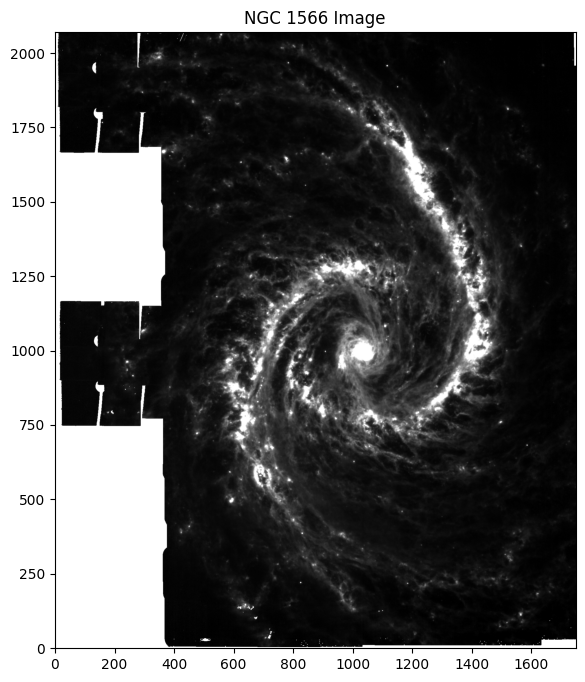

In [59]:
plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.title("NGC 1566 Image")
plt.show()

In [60]:
data_clean = np.nan_to_num(data, nan=0.0)

In [61]:
p1, p99 = np.percentile(data_clean, (1, 99))
data_clipped = np.clip(data_clean, p1, p99)

data_norm = (data_clipped - p1) / (p99 - p1)

In [62]:
print (data_norm.shape)
print (data_norm.max())

(2070, 1750)
1.0


In [63]:
# saving ngc 628 png file

# Does directory exist?
os.makedirs("../data/processed/images", exist_ok=True)

# Saving normalized image
np.save("../data/processed/images/ngc1566_norm.npy", data_norm)

In [64]:
# now sanity check

loaded = np.load("../data/processed/images/ngc1566_norm.npy")
print(loaded.shape, loaded.min(), loaded.max())

(2070, 1750) 0.0 1.0


In [65]:
import pandas as pd

df = pd.read_csv(catalogue_path)

print(df.head())
print(df.columns)

    X_PIX  Y_PIX  SEMI_MAJ_PIX
0  1322.0  157.0     50.989230
1  1521.0  134.0     25.539063
2  1453.0  135.0     17.423007
3  1722.0  216.0     17.046931
4  1751.0  314.0     41.581082
Index(['X_PIX', 'Y_PIX', 'SEMI_MAJ_PIX'], dtype='str')


In [66]:
wcs = WCS(header)
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 64.92768967358889 -54.926893846735695
CRPIX : 2404.9050045066624 1393.2005807528071
PC1_1 PC1_2  : -0.9996839093183195 -0.02514123008211861
PC2_1 PC2_2  : -0.02514123008211861 0.9996839093183195
CDELT : 3.08096374837808e-05 3.08096374837808e-05
NAXIS : 4803  2796


Set DATE-AVG to '2022-11-22T12:26:50.872' from MJD-AVG.
Set DATE-END to '2022-11-22T15:09:03.284' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.727539 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564098702.386 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [67]:
x_pix = df['X_PIX'].tolist()      
y_pix = df['Y_PIX'].tolist()

semi_maj_pixels = df['SEMI_MAJ_PIX'].tolist()  # Third column is r


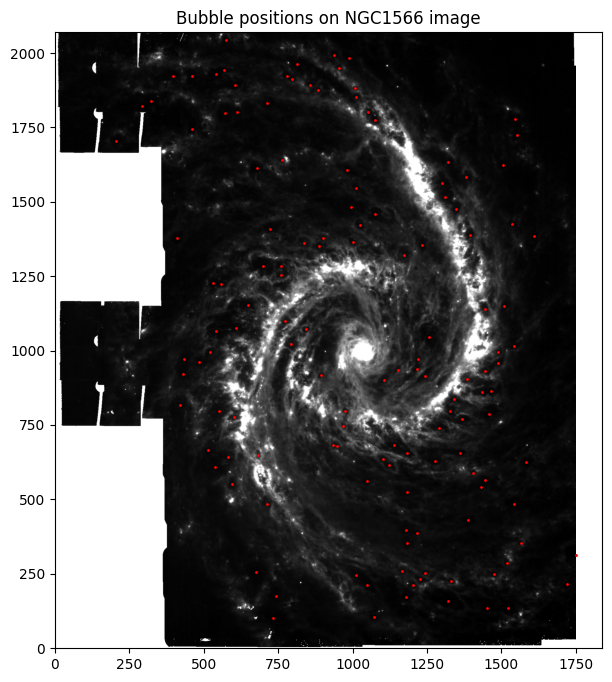

In [68]:
# sanity check  

plt.figure(figsize=(8, 8))
# plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))

plt.scatter(x_pix, y_pix, s=1, color='red')
plt.title("Bubble positions on NGC1566 image")

plt.show()

In [70]:
mask = np.zeros(data_norm.shape, dtype=np.uint8)     

In [122]:

height, width = mask.shape

for i in range(len(df)):
    x0 = x_pix[i]
    y0 = y_pix[i]

    a = semi_maj_pixels[i]

    if np.isnan(x0) or np.isnan(y0) or np.isnan(a) :
        continue

    x0 = int(round(x0))
    y0 = int(round(y0))
    a = int(round(a))
    
    rr, cc = disk(r= y0,
                  c= x0, 
                  radius= a, 
                  shape=mask.shape)

    mask[rr, cc] = 1

TypeError: disk() got an unexpected keyword argument 'r'

In [106]:
mask = np.zeros(data_norm.shape, dtype=np.uint8)

height, width = mask.shape

for i in range(len(df)):
    x0 = df.loc[i, "X_PIX"]
    y0 = df.loc[i, "Y_PIX"]
    r = df.loc[i, "SEMI_MAJ_PIX"]

    if np.isnan(x0) or np.isnan(y0) or np.isnan(r):
        continue

    x0 = int(round(x0))
    y0 = int(round(y0))
    r = int(round(r))

    rr, cc = disk(
        center=(y0, x0),
        radius=r,
        shape=mask.shape
    )

    mask[rr, cc] = 1

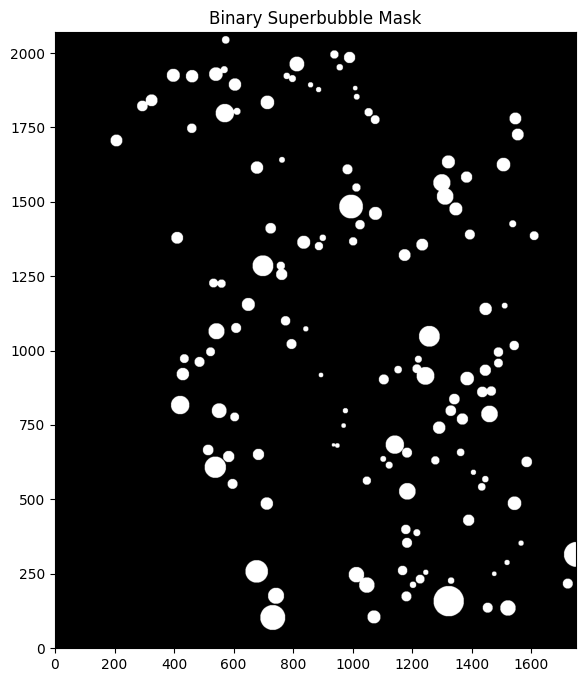

In [124]:
plt.figure(figsize=(8, 8))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Binary Superbubble Mask")
plt.show()

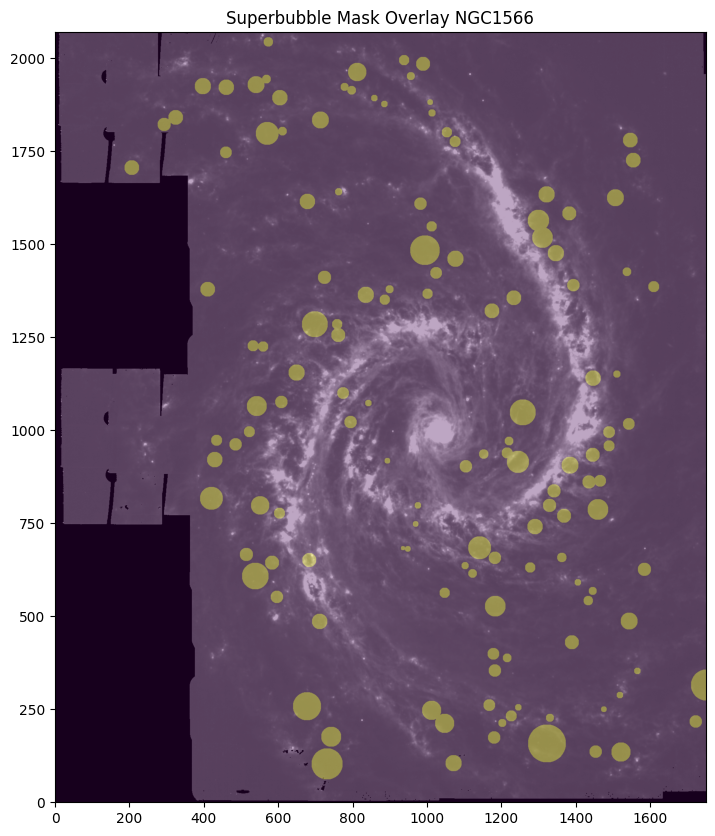

In [125]:
plt.figure(figsize=(10, 10))
plt.imshow(data_norm, origin="lower", cmap="gray")
plt.imshow(mask, origin="lower", alpha=0.35)
plt.title("Superbubble Mask Overlay NGC1566")

overlayabc_path = os.path.join(output_file,"ngc1566_superbubble_mask_overlay.png")

plt.savefig(overlayabc_path, dpi=300, bbox_inches="tight")

plt.show()


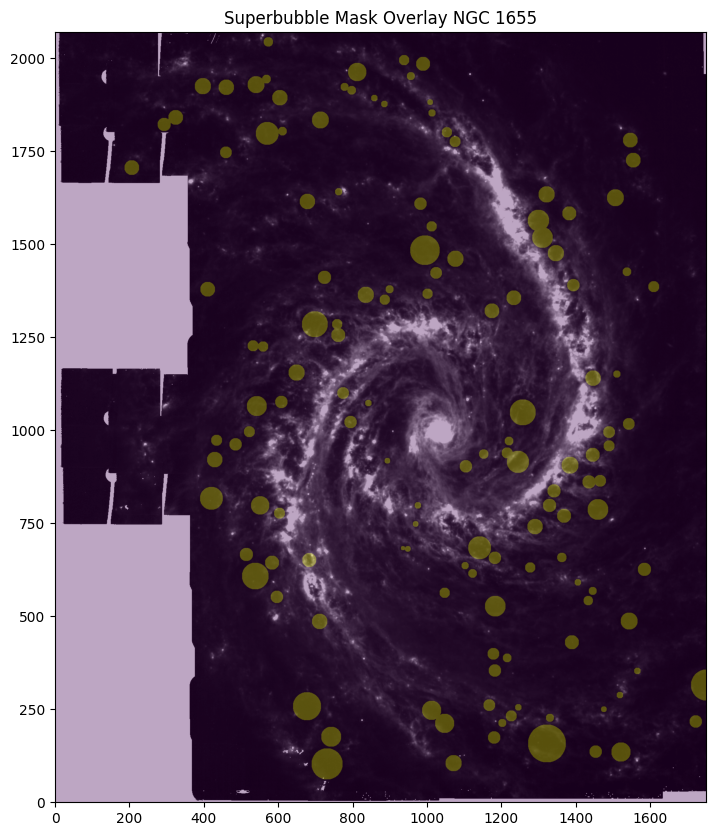

In [127]:
# saving mask overlay png file

plt.figure(figsize=(10, 10))
plt.imshow(data, origin="lower", cmap="gray",
           vmin=np.nanpercentile(data, 1),
           vmax=np.nanpercentile(data, 99))
plt.imshow(mask, origin="lower", alpha=0.35)
    
plt.title("Superbubble Mask Overlay NGC 1655")

plt.savefig(
    "../outputs/figures/ngc1566_superbubble_mask_overlay.png",
    dpi=300,
    bbox_inches="tight"
    )

plt.show()

In [128]:
os.makedirs("../data/processed/masks", exist_ok=True)

np.save("../data/processed/masks/ngc1566_norm_mask.npy", mask)

In [129]:
loaded = np.load("../data/processed/masks/ngc1566_norm_mask.npy")
print(loaded.shape, loaded.min(), loaded.max())

(2070, 1750) 0 1


In [130]:
# !pip install tqdm

import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [131]:
# IMAGE_PATH = "../data/processed/images/ngc628_f770w_norm.npy"
# MASK_PATH = "../data/processed/masks/ngc628_f770w_norm_mask.npy"
OUTPUT_DIR = "../data/processed/patches"


PATCH_SIZE = 256
STRIDE = 128  # liitle overlap 

# THRESHOLD = 0.05
LOW_THRESHOLD = 0.001   # negative patch threshold
HIGH_THRESHOLD = 0.05   # positive patch threshold


In [132]:
image = data_norm

# Ensuring binary mask
mask = (mask > 0).astype(np.float32)

In [133]:
# small sanity check
print("Image shape:", image.shape, "dtype:", image.dtype, "min/max:", image.min(), image.max())
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "min/max:", mask.min(), mask.max())
print("Bubble pixels:", int(mask.sum()))

unique_vals = np.unique(mask)
print("Mask unique values:", unique_vals[:10])

Image shape: (2070, 1750) dtype: float64 min/max: 0.0 1.0
Mask shape: (2070, 1750) dtype: float32 min/max: 0.0 1.0
Bubble pixels: 167228
Mask unique values: [0. 1.]


In [134]:
assert image.shape == mask.shape, "Image and mask must have the same height and width."
assert image.ndim == 2, "Expected image to be a 2D array."
assert mask.ndim == 2, "Expected mask to be a 2D array."
assert mask.max() <= 1 and mask.min() >= 0, "Mask must be binary or in [0, 1]."
# assert mask.sum() > 0, "Mask contains no bubble pixels"

In [135]:
image = image.astype(np.float32)

# for Training image
denom = image.max() - image.min()
if denom > 0:
    image = (image - image.min()) / denom
else:
    image = np.zeros_like(image)

In [136]:
def extract_patches(image, mask, patch_size=256, stride=128, low_threshold=0.009, high_threshold=0.01):
    H, W = image.shape

    pos_patches = []
    weak_patches = []
    neg_patches = []

    # adding "+1" to include edge patches
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            
            img_patch = image[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            bubble_ratio = np.sum(mask_patch) / (patch_size**2)

            if bubble_ratio >= high_threshold:
                pos_patches.append((img_patch, mask_patch))
            elif bubble_ratio >= low_threshold:
                weak_patches.append((img_patch, mask_patch))
            else:
                neg_patches.append((img_patch, mask_patch))
    
    return pos_patches, weak_patches, neg_patches

In [137]:
np.random.seed(42)

pos, weak, neg = extract_patches(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD)

print(f"Positive patches: {len(pos)}")
print(f"Weak patches: {len(weak)}")
print(f"Negative patches: {len(neg)}")

Positive patches: 77
Weak patches: 64
Negative patches: 39


In [138]:
np.random.shuffle(pos)
np.random.shuffle(weak)
np.random.shuffle(neg)

n_strong = len(pos)
n_weak = min(len(weak), n_strong)
n_neg = min(len(neg), n_strong // 2)

dataset = pos + weak[:n_weak] + neg[:n_neg]

np.random.shuffle(dataset)

print(f"Dataset: {len(dataset)}")

Dataset: 179


In [139]:
X = np.array([d[0] for d in dataset], dtype=np.float32)
Y = np.array([d[1] for d in dataset], dtype=np.float32)

# Adding channel dimension for CNN
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

assert X.shape == Y.shape
assert X.ndim == 4
assert Y.ndim == 4

X shape: (179, 256, 256, 1)
Y shape: (179, 256, 256, 1)


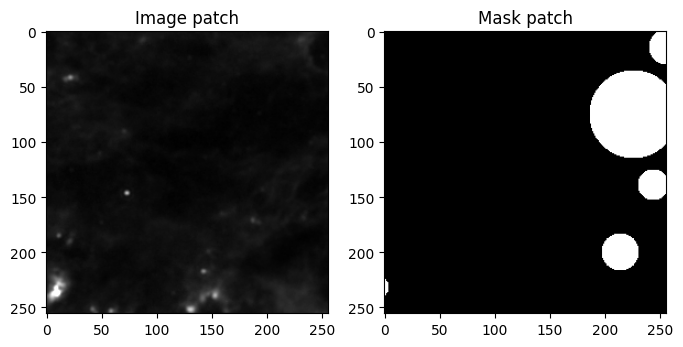

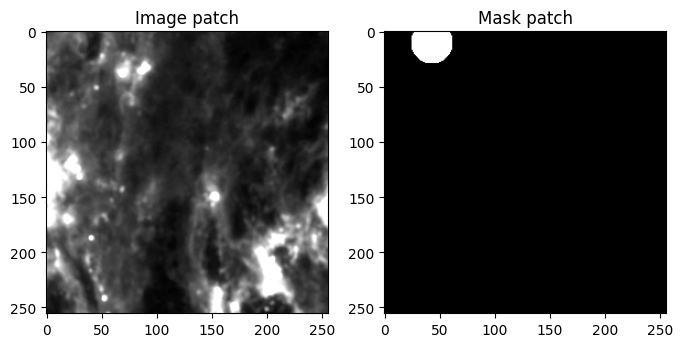

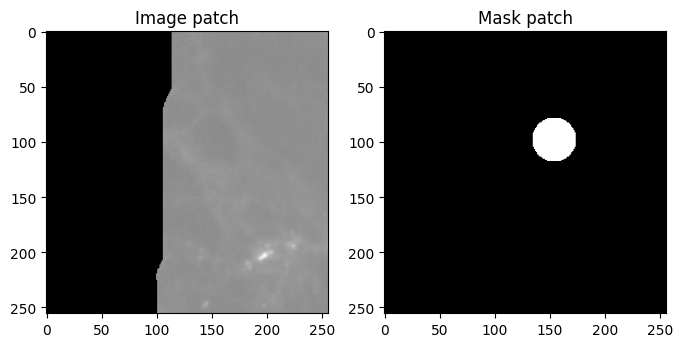

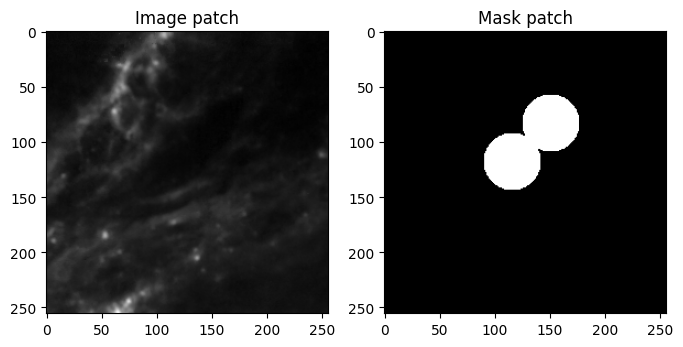

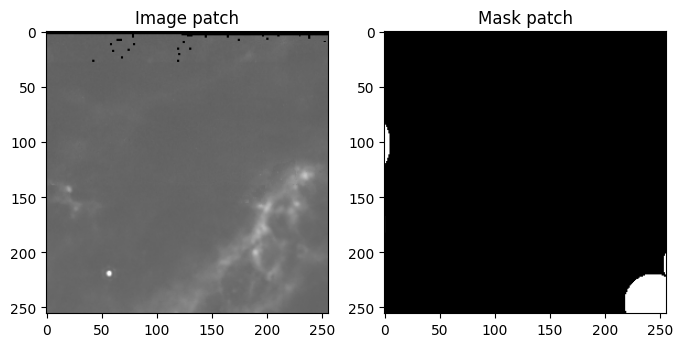

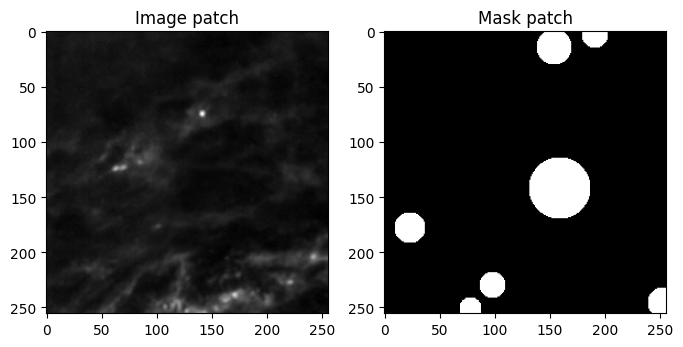

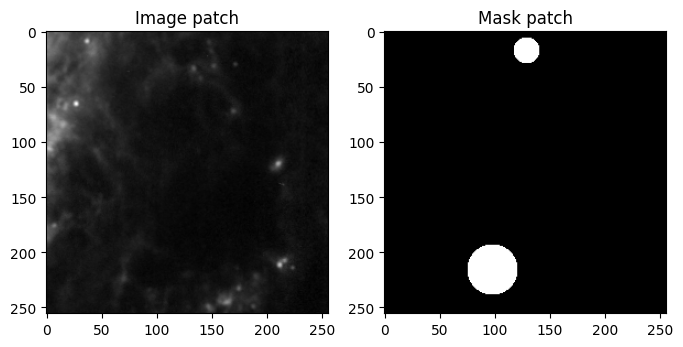

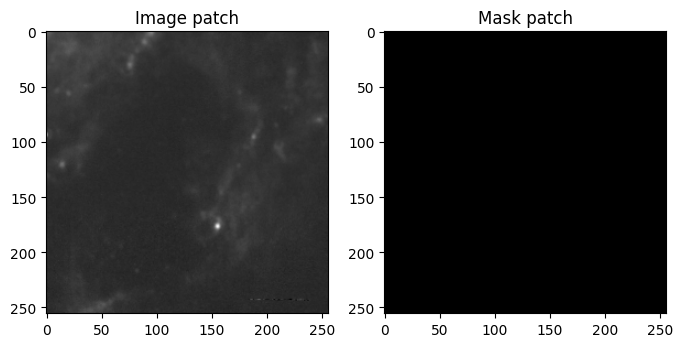

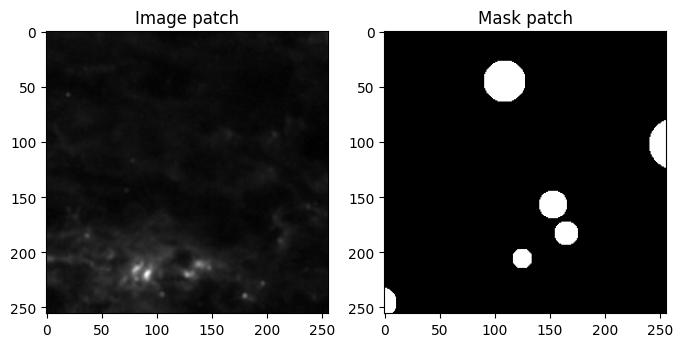

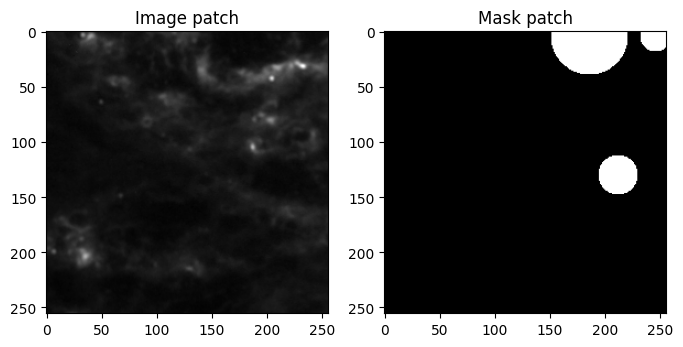

In [140]:
# sanity check

for i in range(10):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Image patch")

    plt.subplot(1,2,2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask patch")

    plt.show()

In [142]:
os.makedirs("../data/processed/patches_ngc1566", exist_ok=True)

np.save("../data/processed/patches/X_ngc1566.npy", X)
np.save("../data/processed/patches/Y_ngc1566.npy", Y)

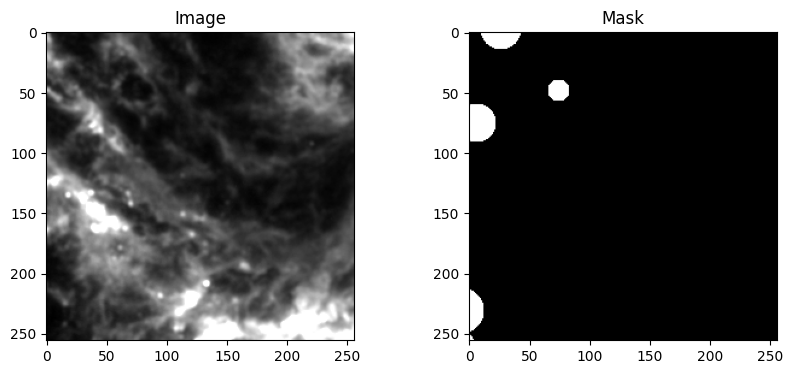

In [143]:
# visual sanity check

import matplotlib.pyplot as plt

idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X[idx].squeeze(), cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[idx].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()